In [145]:
# imports
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
from sklearn import tree

In [146]:
# data load
base_data = pd.read_csv("./fsae_data/2025/raw-data.csv")

cost_data = pd.read_csv("./fsae_data/2025/fsae_cost_results.csv")
cost_data = cost_data.drop(columns=["Place", "Car Num", "Penalty", "Score", "Penalty"])
merged_data = pd.merge(base_data, cost_data, on = 'Team', how = "outer")

efficiency_data = pd.read_csv("./fsae_data/2025/fsae_efficiency_results.csv")
efficiency_data = efficiency_data.drop(columns = ["Place", "Car Num", "Fuel Efficiency Score"])
merged_data = pd.merge(merged_data, efficiency_data, on= 'Team', how = 'outer')

presentation_data = pd.read_csv("./fsae_data/2025/fsae_presentation_results.csv")
presentation_data = presentation_data.drop(columns = ["Place", "Car Num", "Score", "Penalty", "Raw Score", "Status"])
merged_data = pd.merge(merged_data, presentation_data, on= 'Team', how = 'outer')

design_data = pd.read_csv("./fsae_data/2025/fsae_presentation_results.csv")
design_data = design_data.drop(columns = ["Place", "Car Num", "Score", "Penalty", "Raw Score", "Status"])
merged_data = pd.merge(merged_data, design_data, on= 'Team', how = 'outer')

accel_data = pd.read_csv("./fsae_data/2025/fsae_accel_results.csv", index_col=False)
accel_data = accel_data[["Team", "Final Best Time"]]
accel_data = accel_data.rename(columns = {"Final Best Time": "Best Acceleration Time"})
#accel_data = accel_data.drop(columns = ["Place", "Car Num", "Run 1 Time", "Run 1 Adj Time", "Run 2 Time", "Run 2 Adj Time", "Run 3 Time", "Run 3 Adj Time", "Run 4 Time", "Run 4 Adj Time"])
merged_data = pd.merge(merged_data, accel_data, on= 'Team', how = 'outer')

autocross_data = pd.read_csv("./fsae_data/2025/fsae_autocross_results.csv", index_col=False)
autocross_data = autocross_data[["Team", "Best Time"]]
autocross_data = autocross_data.rename(columns = {"Best Time": "Best Autocross Time"})
#autocross_data = autocross_data.drop(columns = ["Place", "Car Num", "Penalty","R1 Time","R1 Cones","R1 Off Course","R1 Adj Time","R2 Time","R2 Cones","R2 Off Course","R2 Adj Time","R3 Time","R3 Cones","R3 Off Course","R3 Adj Time","R4 Time","R4 Cones","R4 Off Course","R4 Adj Time"])
merged_data = pd.merge(merged_data, autocross_data, on= 'Team', how = 'outer')

endurance_data = pd.read_csv("./fsae_data/2025/fsae_endurance_results.csv", index_col=False)
endurance_data = endurance_data.drop(columns = ["Place", "Car Num", "Cones", "Endurance Score"])
endurance_data = endurance_data.rename(columns = {"Time": "Endurance Time", "Other Penalty": "Endurance Penalty", "Adjusted Time": "Adjusted Endurance Time", "Time Score": "Endurance Time Score", "Laps": "Endurance Laps", "Laps Score": "Endurance Laps Score"})
merged_data = pd.merge(merged_data, endurance_data, on= 'Team', how = 'outer')

skidpad_data = pd.read_csv("./fsae_data/2025/fsae_skidpad_results.csv", index_col=False)
skidpad_data = skidpad_data[["Team", "Best Time"]]
skidpad_data = skidpad_data.rename(columns = {"Best Time": "Best Skidpad Time"})
merged_data = pd.merge(merged_data, skidpad_data, on= 'Team', how = 'outer')


team_data = pd.read_csv("./fsae_data/2025/fsae_team_info.csv", index_col=False)
team_data = team_data[["Team", "Engine Cylinders", "Engine Displacement (cc)", "Weight (kg)"]]
merged_data = pd.merge(merged_data, team_data, on= 'Team', how = 'outer')

#print(merged_data)

In [147]:
# Clean place data
placement_new = pd.DataFrame.copy(merged_data)
placement_new = placement_new.dropna(subset=["Place"])
unranked = merged_data[merged_data["Place"] == "Unranked"]
placement_new = placement_new[placement_new.Place != "Unranked"]

tied_cases = placement_new["Place"].str.contains('T')
#tied_cases = tied_cases.fillna(False)
tied = placement_new[tied_cases]
tied["Place"] = tied["Place"].str[:-2]
placement_new = placement_new[~tied_cases]
placement_new = pd.concat([placement_new, tied], ignore_index = True)

placement_new["Place"] = placement_new["Place"].astype(int)
placement_new = placement_new.reset_index(drop = True)
adjustment = pd.DataFrame.copy(placement_new)
for i in range(len(placement_new)):
    if placement_new.iloc[i]["Place"] == 1:
        adjustment.at[i,"Place"] = "1"
    elif placement_new.iloc[i]["Place"] <= 5:
        adjustment.at[i,"Place"] = "<=5"
    elif placement_new.iloc[i]["Place"] <= 10:
        adjustment.at[i,"Place"] = "<=10"
    elif placement_new.iloc[i]["Place"] <= 25:
        adjustment.at[i,"Place"] = "<=25"
    elif placement_new.iloc[i]["Place"] <= 50:
        adjustment.at[i,"Place"] = "<=50"
    elif placement_new.iloc[i]["Place"] <= 75:
        adjustment.at[i,"Place"] = "<=75"
    elif placement_new.iloc[i]["Place"] <= 100:
        adjustment.at[i,"Place"] = "<=100"
    else:
        adjustment.at[i,"Place"] = ">100"

placement_new["Place"] = adjustment["Place"]
placement_new = placement_new.replace("DNF", np.nan)

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
#print(placement_new)

C:\Users\gsant\AppData\Local\Temp\ipykernel_16532\751231791.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tied["Place"] = tied["Place"].str[:-2]
C:\Users\gsant\AppData\Local\Temp\ipykernel_16532\751231791.py:29: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '<=75' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  adjustment.at[i,"Place"] = "<=75"


In [148]:
# Clean cost data
cost_new = pd.DataFrame.copy(placement_new)
cost_new["Adjusted Cost"] = (cost_new["Adjusted Cost"].str.replace('[$, ]', '', regex=True).astype(float))

In [149]:
clean_data = pd.DataFrame.copy(cost_new)

In [150]:
def create_decision_tree(model, X):
    plt.figure(figsize=(45,15))
    tree.plot_tree(
        model,
        feature_names=X.columns,
        class_names=model.classes_,
        filled=True,
        rounded=True,
        fontsize=10
    )
    plt.show()

In [151]:
# Overall Place Decision Tree
X = clean_data[["Best Acceleration Time", "Best Autocross Time", "Best Skidpad Time", "Endurance Laps", "Adjusted Endurance Time", "Engine Cylinders", "Engine Displacement (cc)", "Weight (kg)", "Adjusted Cost"]]
y = clean_data["Place"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

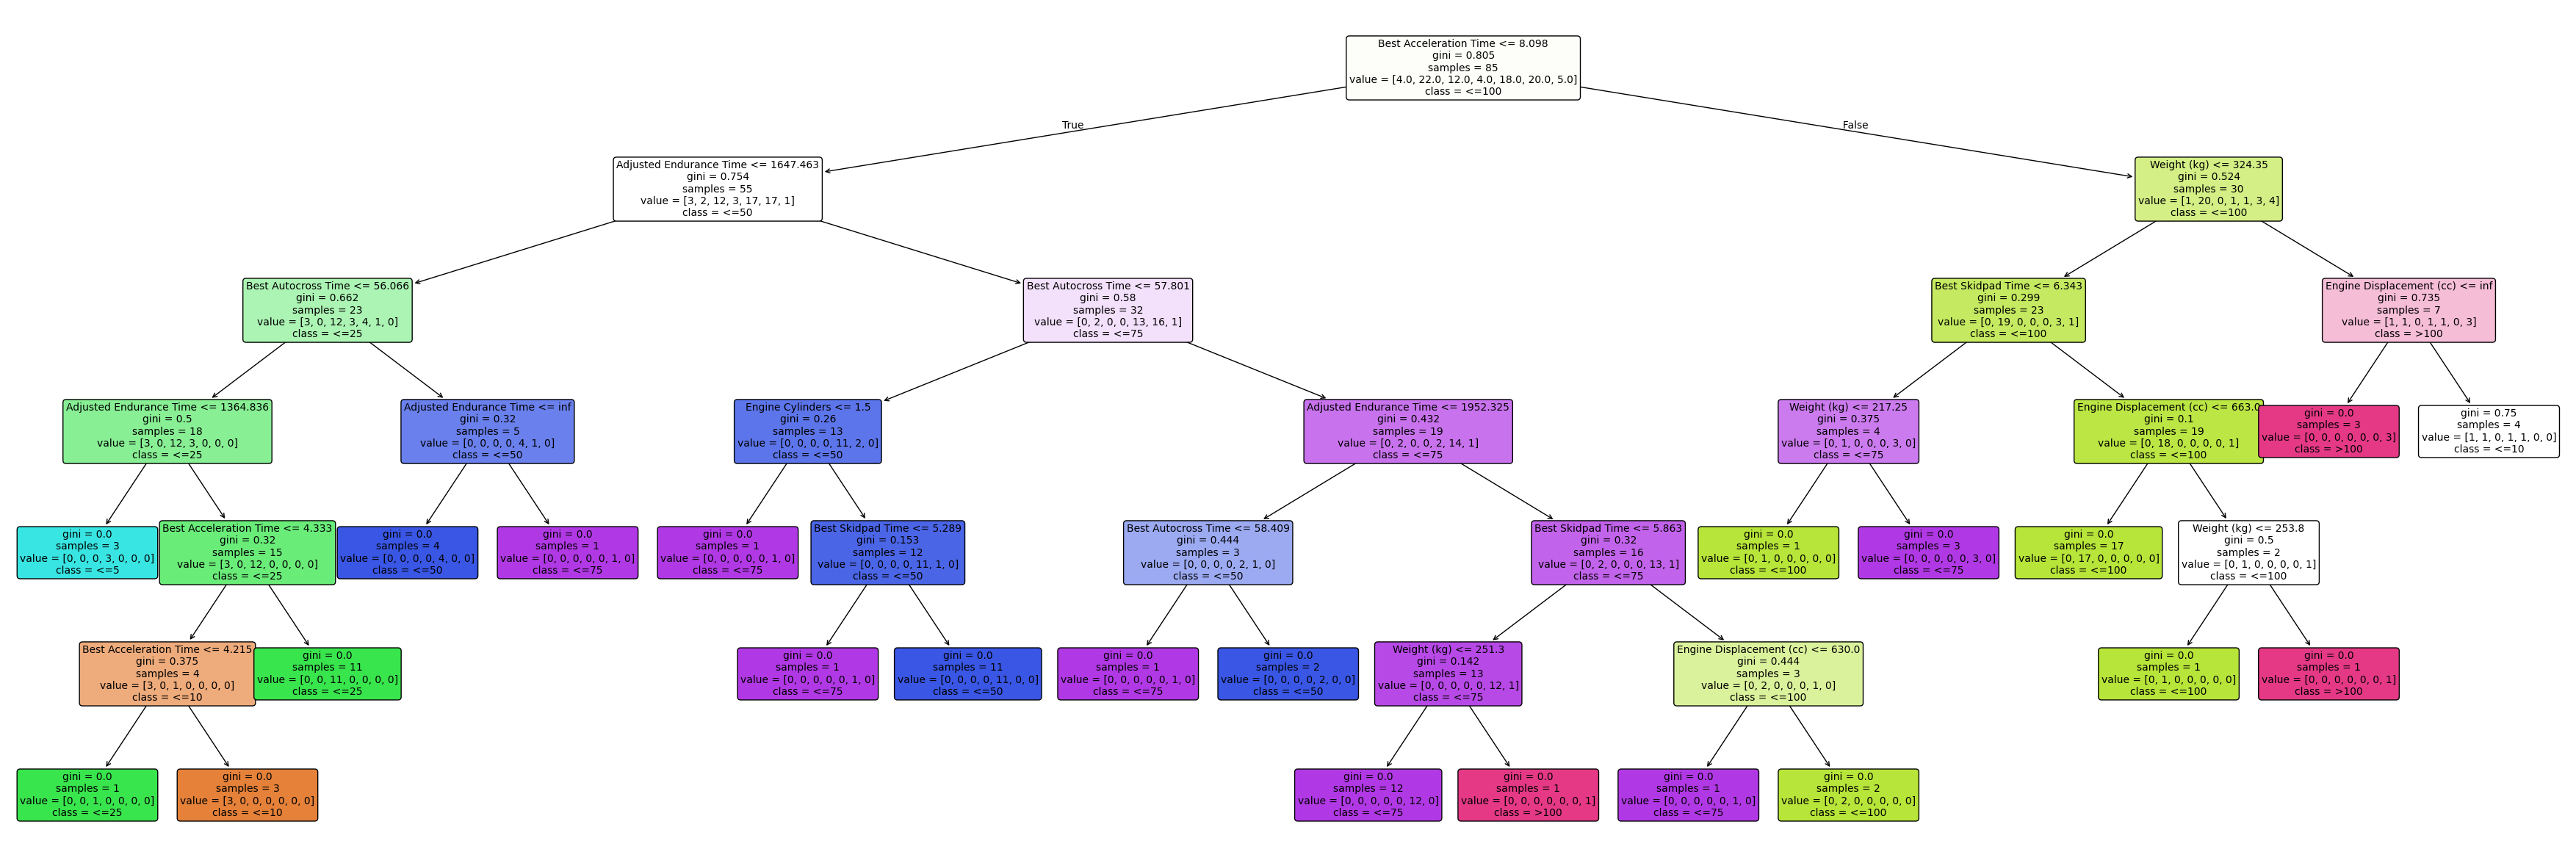

In [152]:
# gini impurity
place_gini_model = DecisionTreeClassifier(criterion="gini", random_state=42)
place_gini_model.fit(X_train, y_train)

create_decision_tree(place_gini_model, X)

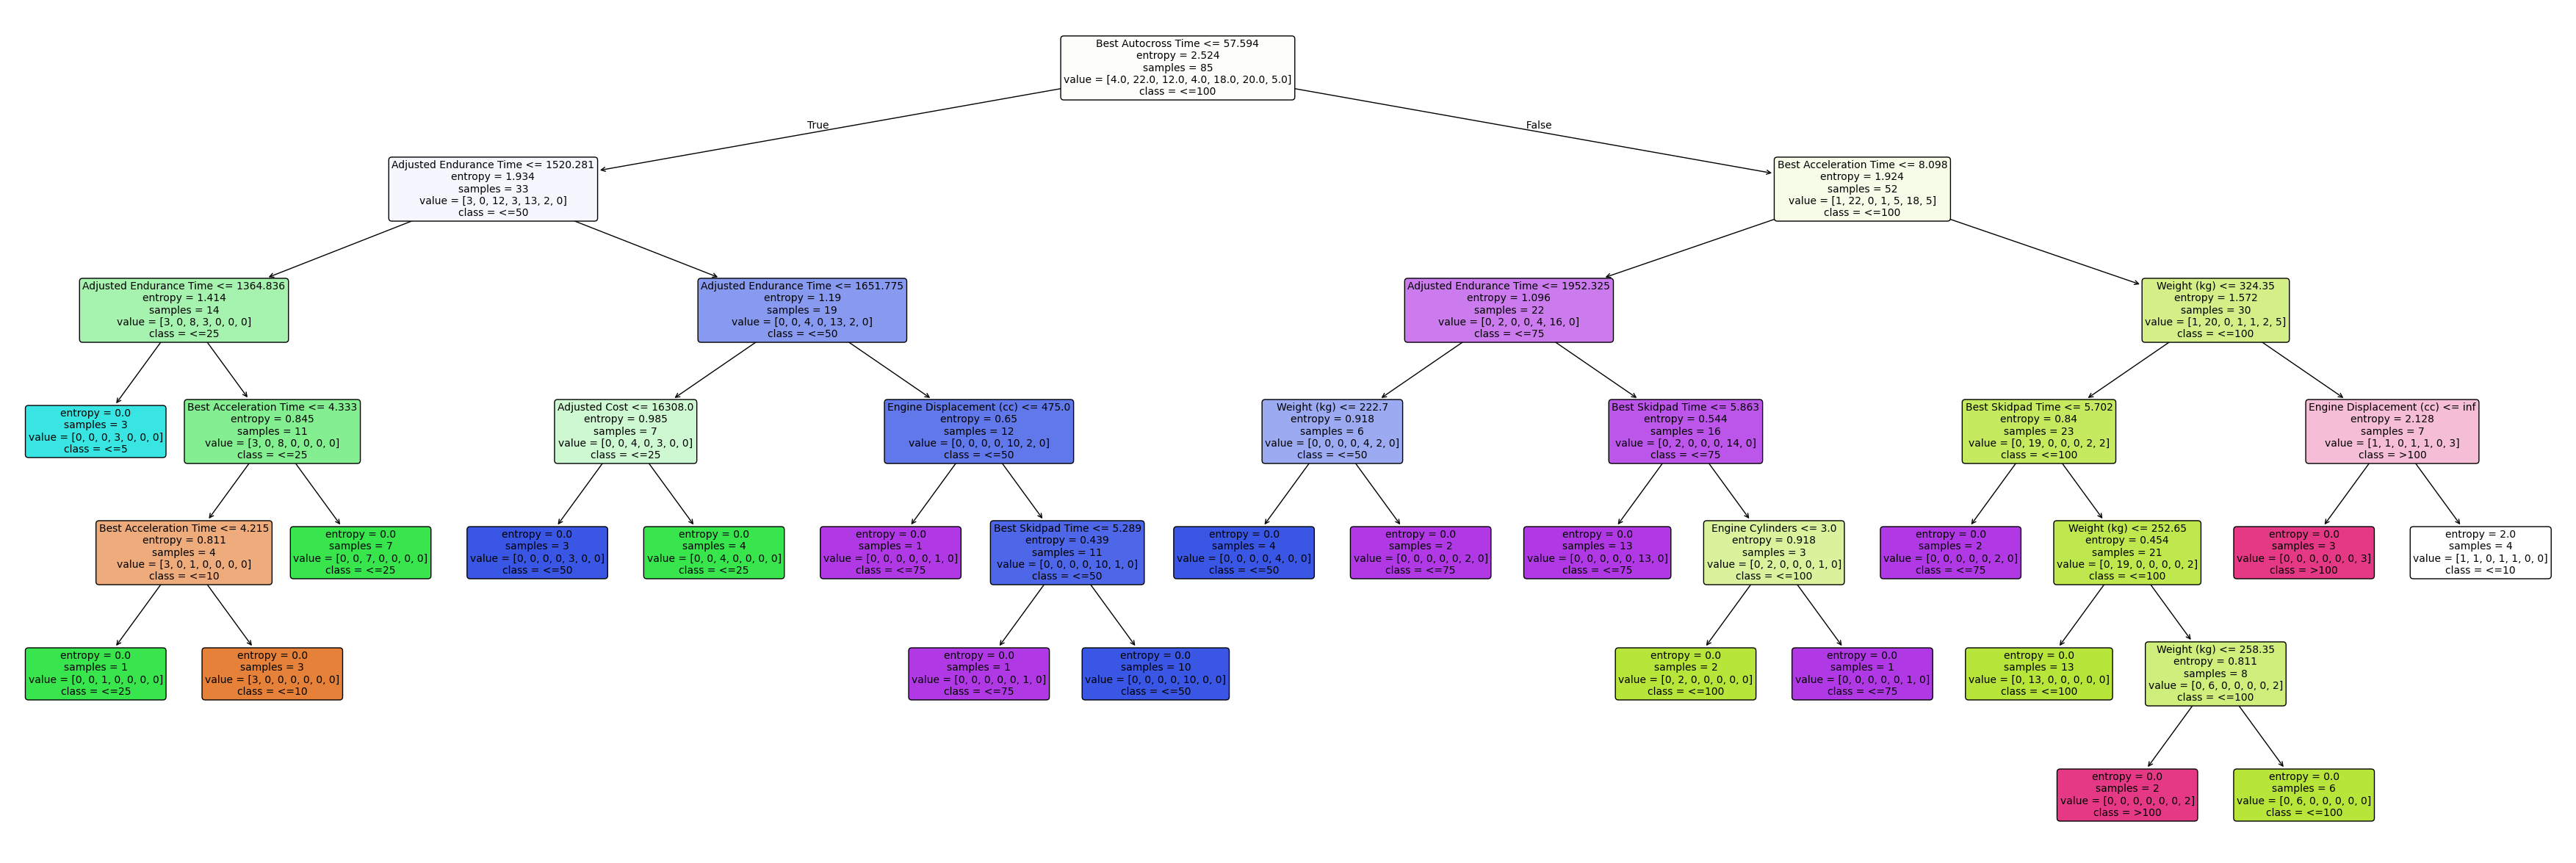

In [153]:
# entropy
place_entropy_model = DecisionTreeClassifier(criterion="entropy", random_state=42)
place_entropy_model.fit(X_train, y_train)

create_decision_tree(place_entropy_model, X)

In [154]:
# Decision Tree Accuracy for Overall Place
gini_y_prediction_place = place_gini_model.predict(X_test)
print("Gini Accuracy: ", accuracy_score(y_test, gini_y_prediction_place) * 100, "%", sep="")
entropy_y_prediction_place = place_entropy_model.predict(X_test)
print("Entropy Accuracy: ", accuracy_score(y_test, entropy_y_prediction_place) * 100, "%", sep="")

Gini Accuracy: 40.909090909090914%
Entropy Accuracy: 50.0%


In [155]:
# Ready acceleration for predictions
acceleration_prediction_data = clean_data.dropna(subset=["Acceleration Score"])
acceleration_prediction_data = acceleration_prediction_data.reset_index()
for i in range(len(acceleration_prediction_data)):
    if acceleration_prediction_data.iloc[i]["Acceleration Score"] == 100:
        acceleration_prediction_data.at[i,"Acceleration Score"] = "100"
    elif acceleration_prediction_data.iloc[i]["Acceleration Score"] > 90:
        acceleration_prediction_data.at[i,"Acceleration Score"] = "<=90"
    elif acceleration_prediction_data.iloc[i]["Acceleration Score"] <= 80:
        acceleration_prediction_data.at[i,"Acceleration Score"] = "<=80"
    elif placement_new.iloc[i]["Acceleration Score"] <= 70:
        acceleration_prediction_data.at[i,"Acceleration Score"] = "<=70"
    elif acceleration_prediction_data.iloc[i]["Acceleration Score"] <= 60:
        acceleration_prediction_data.at[i,"Acceleration Score"] = "<=60"
    elif acceleration_prediction_data.iloc[i]["Acceleration Score"] <= 50:
        acceleration_prediction_data.at[i,"Acceleration Score"] = "<=50"
    else:
        acceleration_prediction_data.at[i,"Acceleration Score"] = "<50"

#print(acceleration_prediction_data)

C:\Users\gsant\AppData\Local\Temp\ipykernel_16532\2351391343.py:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '<=80' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  acceleration_prediction_data.at[i,"Acceleration Score"] = "<=80"


In [156]:
X = acceleration_prediction_data[["Best Autocross Time", "Best Skidpad Time", "Endurance Laps", "Adjusted Endurance Time", "Engine Cylinders", "Engine Displacement (cc)", "Weight (kg)", "Adjusted Cost", "Presentation Score", "Design Score", "Average Adjusted Laptime"]]
y = acceleration_prediction_data["Acceleration Score"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

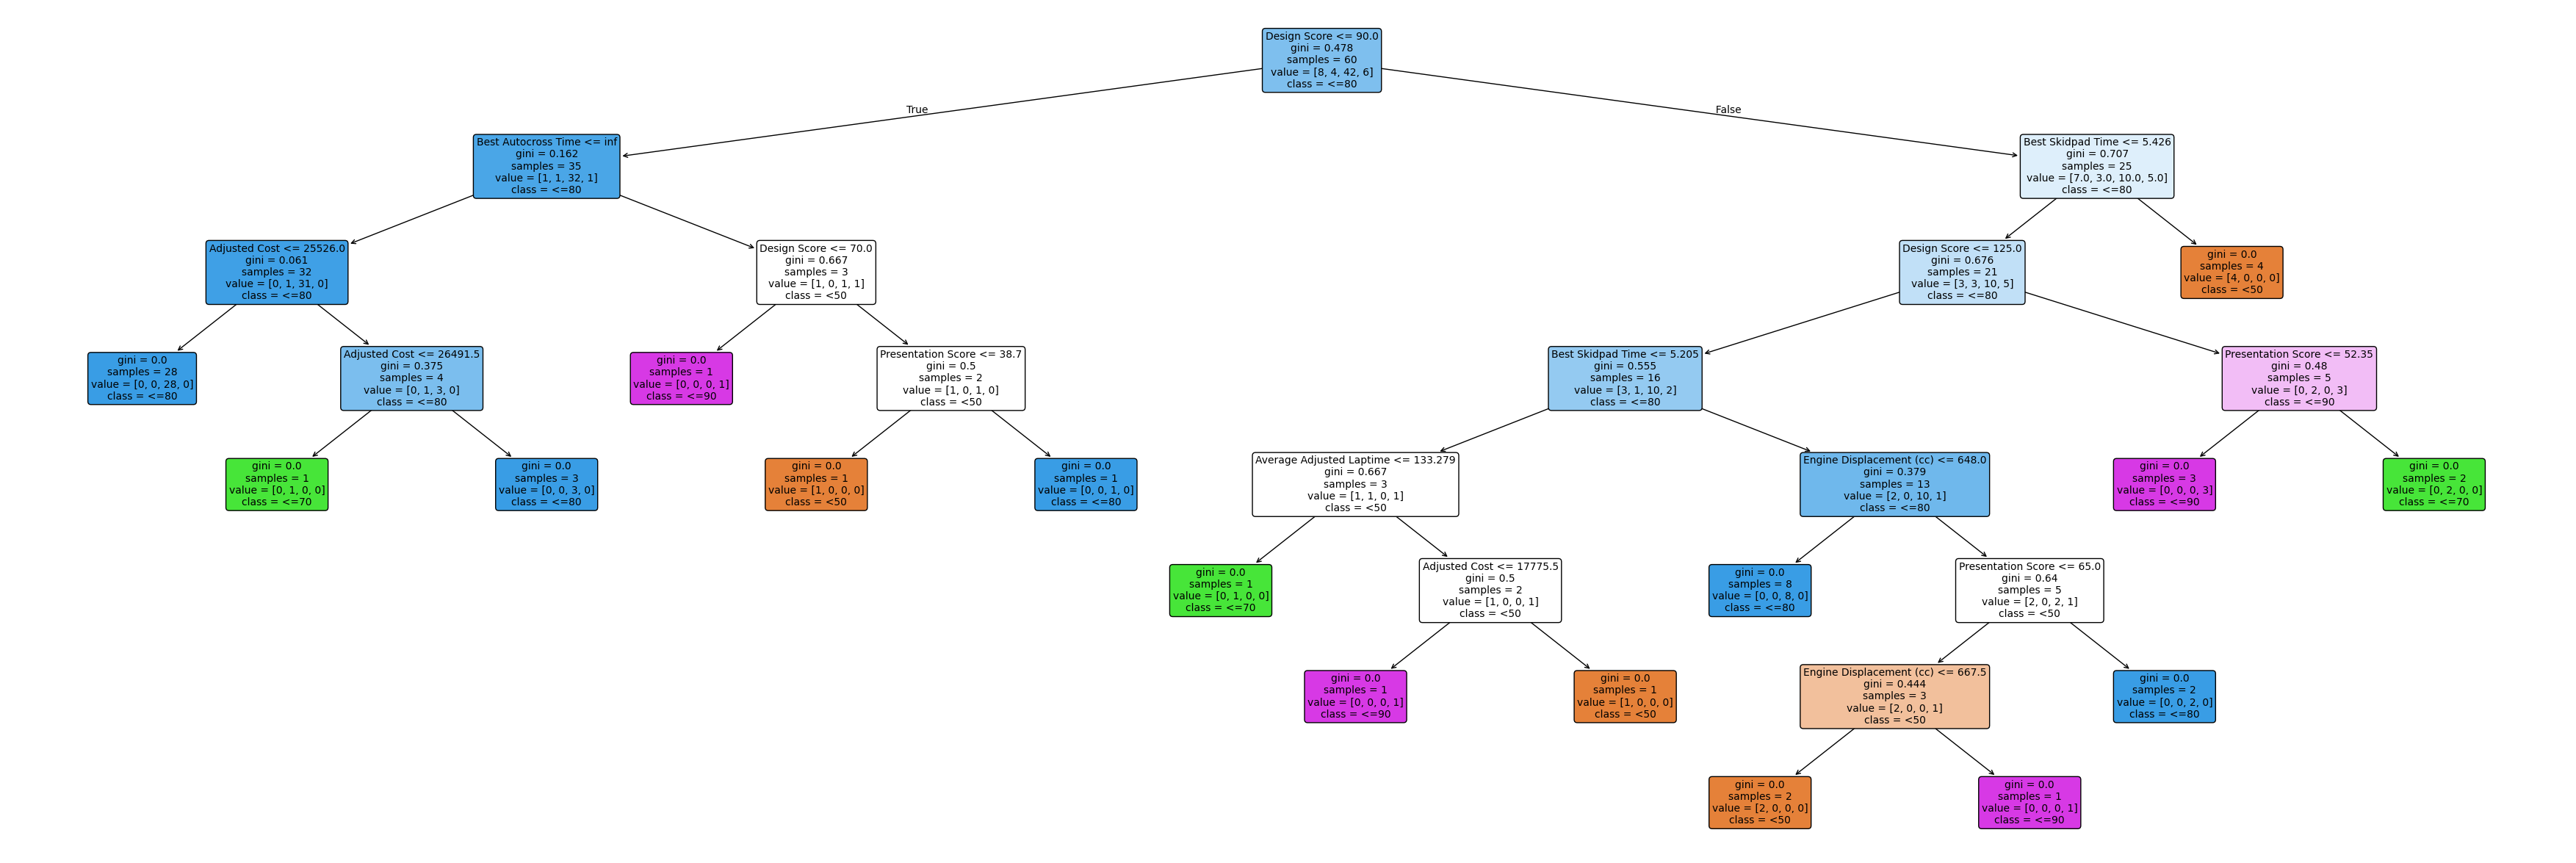

In [157]:
# gini impurity
accel_gini_model = DecisionTreeClassifier(criterion="gini", random_state=42)
accel_gini_model.fit(X_train, y_train)

create_decision_tree(accel_gini_model, X)

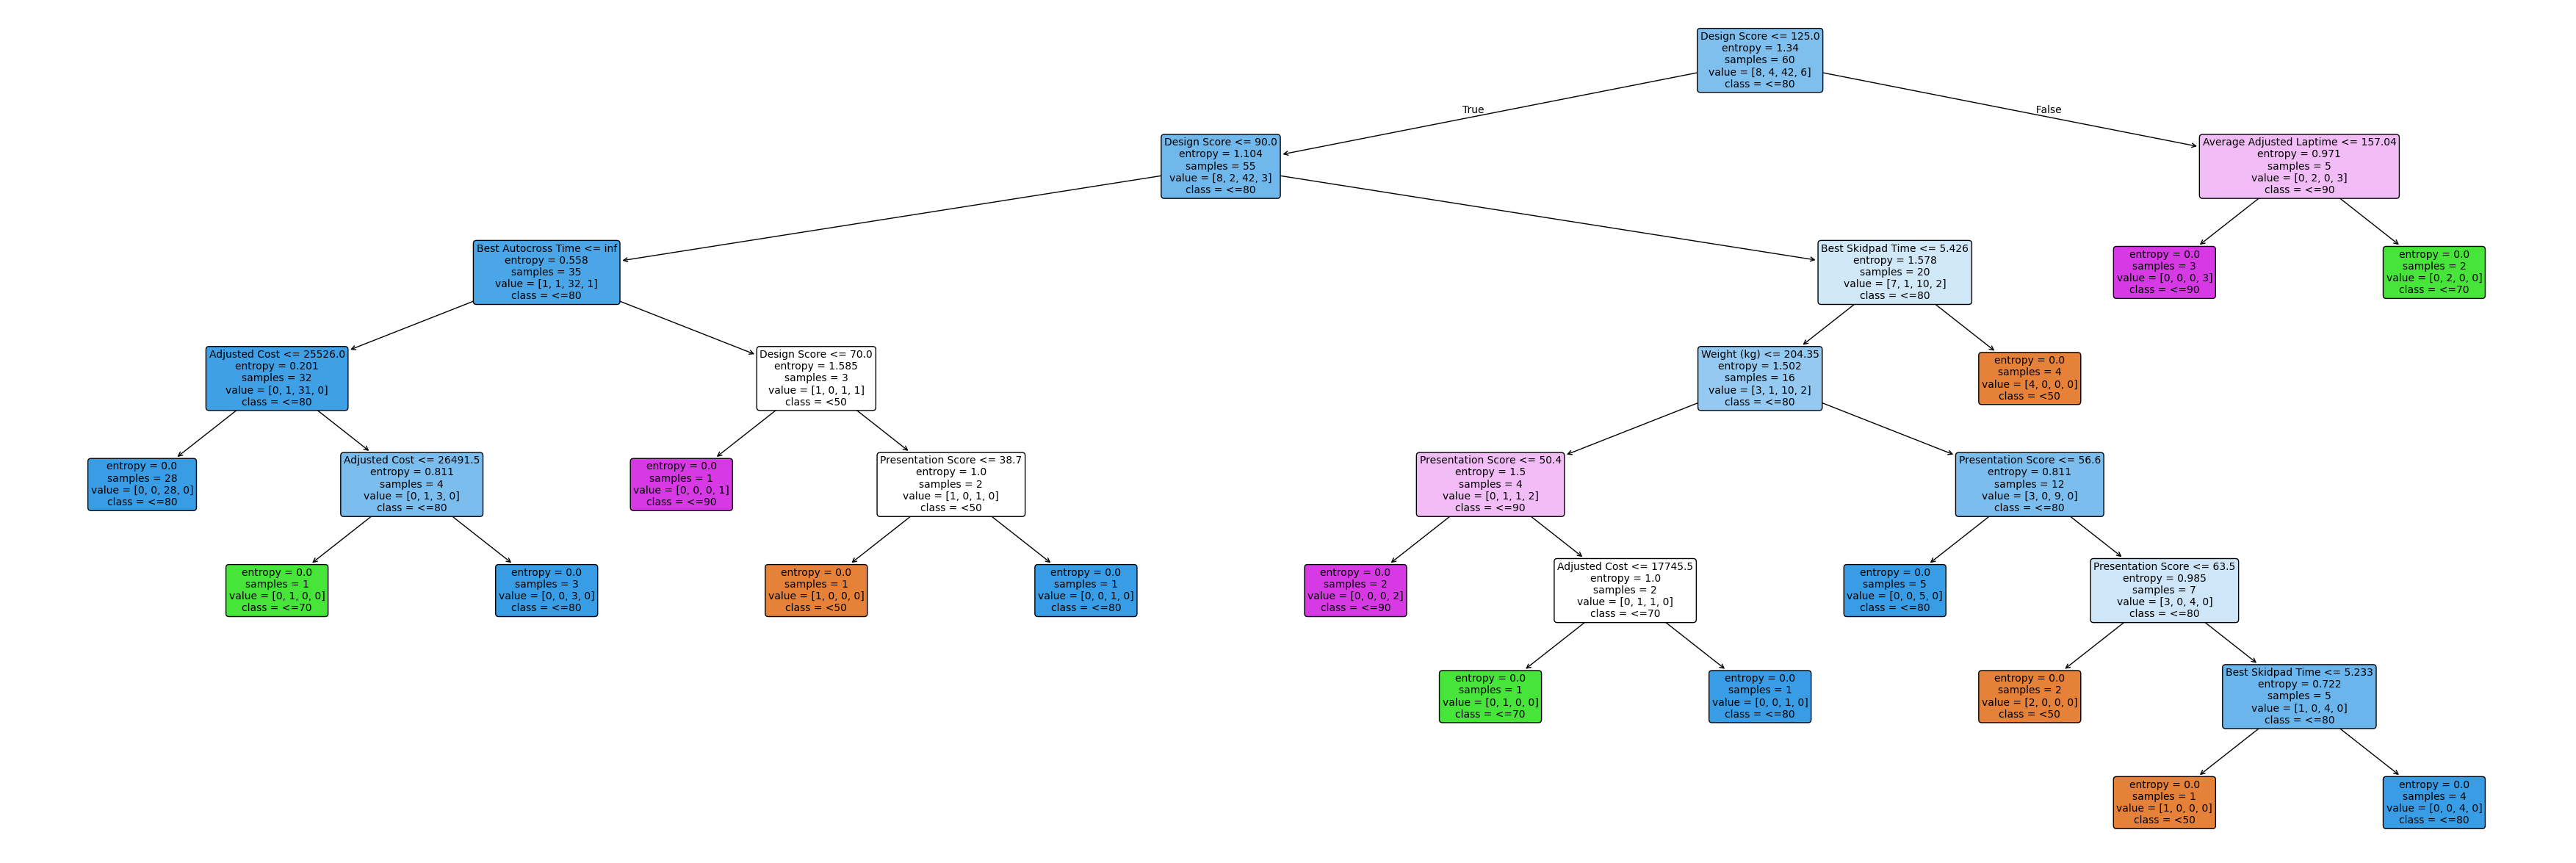

In [158]:
# entropy
accel_entropy_model = DecisionTreeClassifier(criterion="entropy", random_state=42)
accel_entropy_model.fit(X_train, y_train)

create_decision_tree(accel_entropy_model, X)

In [159]:
# Decision Tree Accuracy for Acceleration Score
gini_y_prediction_accel = accel_gini_model.predict(X_test)
print("Gini Accuracy: ", accuracy_score(y_test, gini_y_prediction_accel) * 100, "%", sep="")
entropy_y_prediction_accel = accel_entropy_model.predict(X_test)
print("Entropy Accuracy: ", accuracy_score(y_test, entropy_y_prediction_accel) * 100, "%", sep="")

Gini Accuracy: 68.75%
Entropy Accuracy: 62.5%
